In [1]:
# Célula 1: Importação e Carregamento
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padronizada
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Carregando dados processados...")
df = pd.read_csv('../data/processed/processed_power_consumption.csv', index_col='Datetime', parse_dates=True)

# Exibe as estatísticas descritivas (Exigência do item 4.3)
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

Carregando dados processados...

--- Estatísticas Descritivas ---


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,1.150391e+01,2.989276e+00,6.454433e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,6.925189e+00,1.997633e+00,3.423209e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,1.000000e+00,3.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.200000e+01,3.000000e+00,6.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,1.800000e+01,5.000000e+00,9.000000e+00
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2.300000e+01,6.000000e+00,1.200000e+01


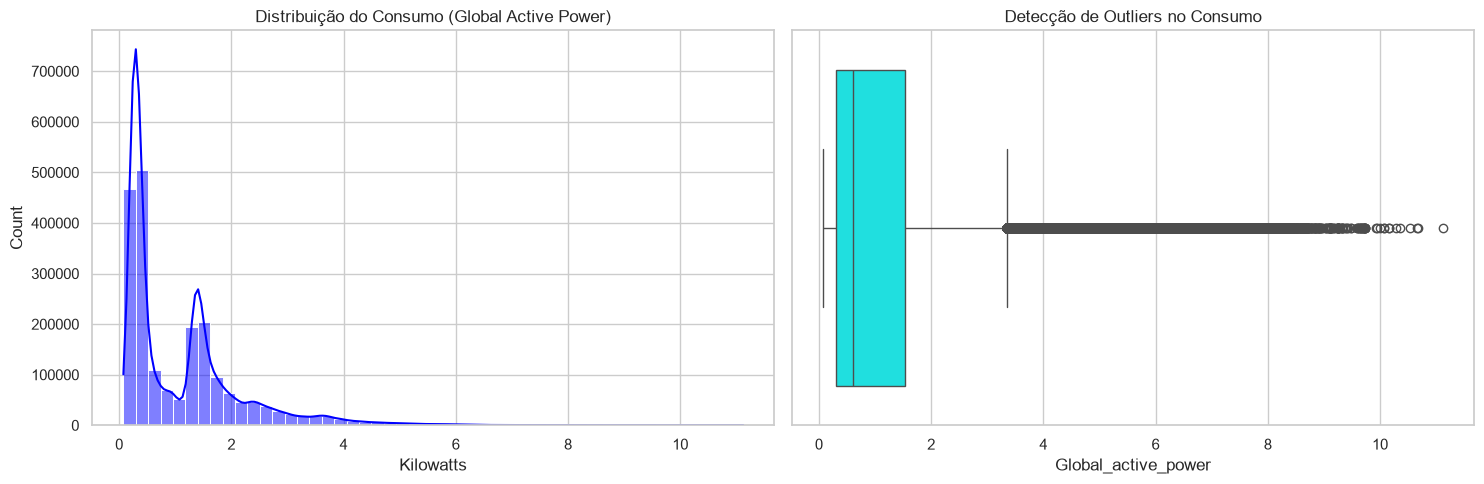

Limite superior para considerar como outlier: 3.36 kW


In [2]:
# Célula 2: Distribuição e Outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma da distribuição
sns.histplot(df['Global_active_power'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribuição do Consumo (Global Active Power)')
axes[0].set_xlabel('Kilowatts')

# Boxplot para visualizar Outliers
sns.boxplot(x=df['Global_active_power'], ax=axes[1], color='cyan')
axes[1].set_title('Detecção de Outliers no Consumo')

plt.tight_layout()
plt.show()

# Tratamento de Outliers usando o Método IQR (Interquartile Range)
Q1 = df['Global_active_power'].quantile(0.25)
Q3 = df['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"Limite superior para considerar como outlier: {limite_superior:.2f} kW")
# Nota para o relatório: O consumo de energia naturalmente tem picos (como ligar um chuveiro elétrico).
# Remover cegamente os outliers pode remover o comportamento real da casa.

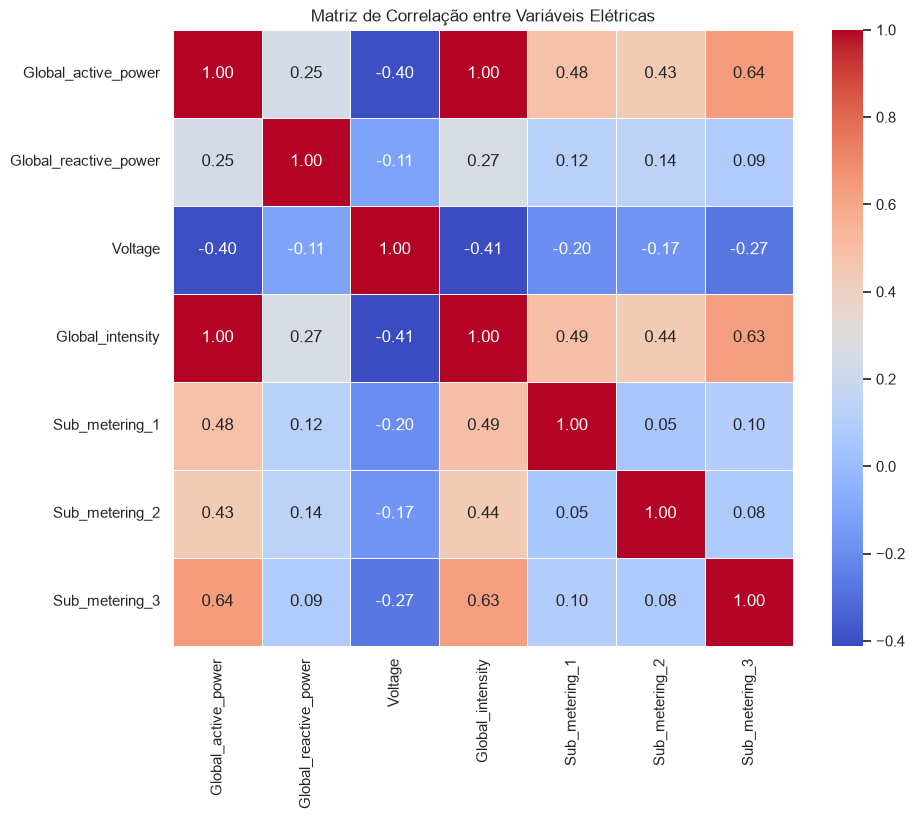

In [3]:
# Célula 3: Matriz de Correlação
plt.figure(figsize=(10, 8))
# Seleciona apenas as colunas numéricas originais para a correlação
cols_correlacao = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                   'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

matriz_corr = df[cols_correlacao].corr()

# Plota um heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Elétricas')
plt.show()

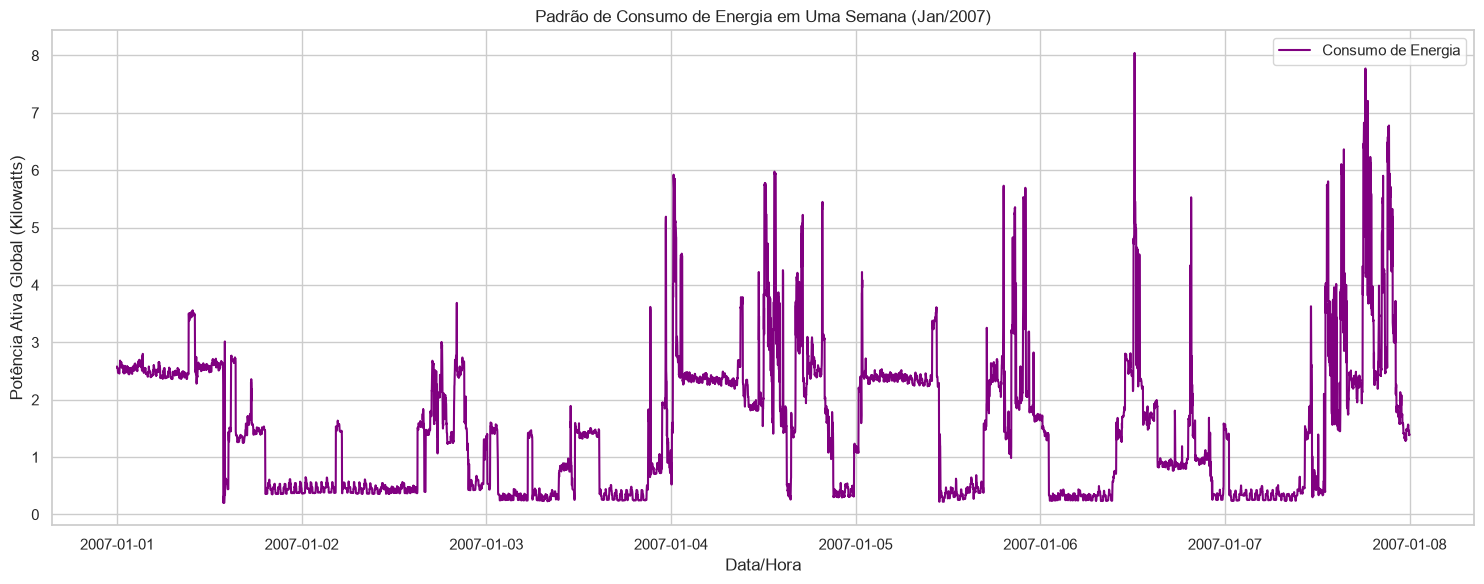

In [4]:
# Célula 4: Visualização Temporal de uma Semana Específica
# Pegando a primeira semana de 2007 como exemplo
semana_exemplo = df.loc['2007-01-01':'2007-01-07']

plt.figure(figsize=(15, 6))
plt.plot(semana_exemplo.index, semana_exemplo['Global_active_power'], label='Consumo de Energia', color='purple')
plt.title('Padrão de Consumo de Energia em Uma Semana (Jan/2007)')
plt.xlabel('Data/Hora')
plt.ylabel('Potência Ativa Global (Kilowatts)')
plt.legend()
plt.tight_layout()
plt.show()